# Import Packages

## Notebook Documentation

This notebook covers the end-to-end process of building, training, and exporting machine learning models for predicting `degree.category` based on educational and demographic data.

### 1. Package Installation and Imports

The notebook begins by installing necessary Python packages using `%pip install`:
- `optuna`: For hyperparameter optimization.
- `optuna_integration`: For Optuna callbacks, specifically `XGBoostPruningCallback`.
- `skl2onnx`: For converting scikit-learn compatible models to ONNX format.
- `onnxruntime`: For running ONNX models.

Subsequently, a range of libraries essential for data manipulation, visualization, machine learning, and imbalance handling are imported:
- `numpy`, `pandas`, `os`, `seaborn`, `matplotlib.pyplot`
- `sklearn.datasets`, `sklearn.preprocessing` (`StandardScaler`, `OrdinalEncoder`, `LabelEncoder`)
- `sklearn.model_selection` (`train_test_split`, `cross_val_score`, `StratifiedKFold`, `GridSearchCV`, `KFold`)
- `sklearn.metrics` (`confusion_matrix`, `ConfusionMatrixDisplay`, `accuracy_score`, `classification_report`, `top_k_accuracy_score`)
- `sklearn.neighbors` (`KNeighborsClassifier`)
- `sklearn.ensemble` (`RandomForestClassifier`)
- `sklearn.feature_selection` (`SelectKBest`, `f_classif`, `VarianceThreshold`, `RFE`, `mutual_info_classif`, `mutual_info_regression`)
- `sklearn.linear_model` (`LogisticRegressionCV`)
- `sklearn.svm` (`SVC`)
- `xgboost` (`XGBClassifier`, `xgb`)
- `imblearn.over_sampling` (`SMOTE`)
- `imblearn.under_sampling` (`RandomUnderSampler`)
- `collections` (`Counter`)
- `sklearn.tree` (`DecisionTreeClassifier`)

### 2. Data Loading

The `education_only_data.csv` dataset is loaded from Google Drive into a pandas DataFrame named `education_only_df`. The `df.info()` method is used to inspect the DataFrame's structure, including column names, non-null counts, and data types.

### 3. Exploratory Data Analysis (EDA)

Basic EDA is performed to understand the dataset's characteristics:
- `education_only_df.describe()`: Provides descriptive statistics for numerical columns.
- `education_only_df.describe(include='object')`: Provides descriptive statistics for categorical columns.
- A correlation heatmap (`sns.heatmap`) is generated for the numerical columns to visualize relationships between them.
- The mean of numerical features is grouped by `degree.focus` to observe trends across different degree concentrations.

### 4. Preprocessing

#### Encoding and Standardization
- A copy of the DataFrame, `df1_encoded`, is created.
- `OrdinalEncoder` is applied to categorical features (`fefs`, `fems`, `gender`) using predefined categories to ensure consistent encoding.
- The target variable `degree.category` is separated into `Y`, and features `X` are created by dropping `degree.focus`, `degree`, and `degree.category`.
- `StandardScaler` is used to standardize the numerical features in `X`.
- `LabelEncoder` is applied to the target variable `Y` to convert categorical labels into numerical format.

#### Feature Selection
- Mutual Information scores (`mutual_info_classif`) are calculated for features against the target variable to identify the most informative features.
- The top 10 features with the highest MI scores are selected, and `X` is updated to include only these selected features.

#### Train Test Split and Resampling
- The dataset is split into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`) using `train_test_split` with a test size of 20%.
- `RandomUnderSampler` is applied to the training data (`X_train`, `y_train`) to address class imbalance, creating `X_train_resampled` and `y_train_resampled`. The class distribution before and after resampling is printed.

### 5. Model Training and Evaluation

A custom function `print_top_k_accuracy_per_class` is defined to calculate and display top-k accuracy for individual classes.

#### Random Forest
- An initial `RandomForestClassifier` is trained with `n_estimators=100` and `max_depth=10`. Training and test accuracies, as well as Top-3 and Top-5 accuracies, are reported. Top-k accuracy per class is also displayed.
- Hyperparameter tuning is performed using Optuna. An `objective` function is defined to maximize Top-5 accuracy, exploring parameters like `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `criterion`. The best parameters and the corresponding Top-5 accuracy are printed.
- A new `RandomForestClassifier` (`rf_tuned`) is trained using the best parameters found by Optuna, and its training and test accuracies are reported, along with Top-5 and Top-10 accuracies.

#### XGBoost
- An initial `XGBClassifier` is trained with `n_estimators=100` and `max_depth=10`. Training and test accuracies, as well as Top-3 and Top-5 accuracies, are reported. Top-k accuracy per class is also displayed.
- Hyperparameter tuning is performed using Optuna. An `objective` function is defined to maximize Top-5 accuracy, incorporating `XGBoostPruningCallback` for early stopping. Parameters like `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `gamma`, `lambda`, `alpha`, `n_estimators`, and `learning_rate` are tuned. The best parameters and the corresponding Top-5 accuracy are printed.
- A new `XGBClassifier` (`xgb_tuned`) is trained using the best parameters from Optuna, and its training and test accuracies are reported, along with Top-3 and Top-5 accuracies.

#### K-Nearest Neighbors (KNN)
- A function `find_optimal_features_and_k` is defined to find the optimal `k` for `KNeighborsClassifier` (though in this notebook, it's run on `X_train_resampled` directly without iterating through features).
- A `KNeighborsClassifier` is trained with `n_neighbors=5` (determined as optimal in a previous run) on the resampled training data. Training and test accuracies, as well as Top-3 and Top-5 accuracies, are reported.

#### GLMNET (Logistic Regression with Elastic Net)
- A `LogisticRegressionCV` model with `penalty='elasticnet'` and `solver='saga'` is trained. Training and test accuracies, as well as Top-5 and Top-10 accuracies, are reported.

#### Support Vector Machine (SVM)
- A `SVC` model with a `linear` kernel and `C=1` is trained. Training and test accuracies are reported. *(Note: `predict_proba` is not directly supported by `SVC` with a linear kernel without `probability=True` during initialization, so top-k accuracy isn't calculated in the notebook for this model).* This was a previous run.

### 6. Export Models

The trained `xgb_tuned` model and preprocessing components (`StandardScaler`, `OrdinalEncoder`, `LabelEncoder`, and `selected_features` list) are exported in various formats for later deployment or use.

#### Joblib
- The `xgb_tuned` model, `scaler`, `encoder`, `le` (label encoder), and `selected_features` list are saved using `joblib.dump` to the `/content/drive/My Drive/IS_II/exported_model` directory.
- A sample prediction pipeline is then demonstrated by loading these `joblib` files, preprocessing sample data, and making a prediction, including top-k predictions.

In [1]:
%pip install optuna
%pip install optuna_integration
%pip install skl2onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegressionCV
from sklearn.svm import SVC
from xgboost import XGBClassifier
import xgboost as xgb
import optuna
from optuna.integration import XGBoostPruningCallback
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_selection import VarianceThreshold, RFE, mutual_info_classif, mutual_info_regression
from sklearn.tree import DecisionTreeClassifier

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [4]:
education_only_df = pd.read_csv('/content/drive/My Drive/IS_II/datasets/education_only_data.csv')
education_only_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466390 entries, 0 to 466389
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ENG.HS           466390 non-null  float64
 1   SC.HS            466390 non-null  float64
 2   MATH.HS          466390 non-null  float64
 3   CR.HS            466390 non-null  float64
 4   NS.HS            466390 non-null  float64
 5   degree           466390 non-null  object 
 6   degree.focus     466390 non-null  object 
 7   gender           466390 non-null  object 
 8   fems             466390 non-null  object 
 9   fefs             466390 non-null  object 
 10  int.s            466390 non-null  float64
 11  comp.s           466390 non-null  float64
 12  wasm.s           466390 non-null  float64
 13  car.s            466390 non-null  float64
 14  t.cred           466390 non-null  int64  
 15  t.parents        466390 non-null  int64  
 16  t.own            466390 non-null  int6

In [5]:
numeric_columns = ['ENG.HS','SC.HS', 'MATH.HS', 'CR.HS', 'NS.HS','int.s', 'comp.s', 'wasm.s', 'car.s', 't.cred', 't.parents', 't.own']

# EDA

In [ ]:
education_only_df.describe()

,ENG.HS,SC.HS,MATH.HS,CR.HS,NS.HS,int.s,comp.s,wasm.s,car.s,t.cred,t.parents,t.own
count,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000,518542.000000
mean,56.013698,55.743697,56.532199,56.373539,56.028266,0.692509,0.803021,0.797484,0.392533,0.300992,0.720767,0.242831
std,14.110778,10.294171,11.357251,10.280244,10.892408,0.461455,0.397717,0.401875,0.488315,0.458690,0.448623,0.428794
min,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,46.000000,49.000000,49.000000,50.000000,48.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,55.840000,55.890000,56.410000,55.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,63.000000,62.000000,63.020000,63.000000,63.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,117.290000,108.280000,120.390000,113.190000,123.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
education_only_df.describe(include='object')

,degree,degree.focus,gender,fems,fefs
count,518542,518542,518542,518542,518542
unique,211,54,2,11,11
top,BUSINESS MANAGEMENT,MANAGEMENT,F,complete secondary school,complete secondary school
freq,47235,75902,313262,132045,144657


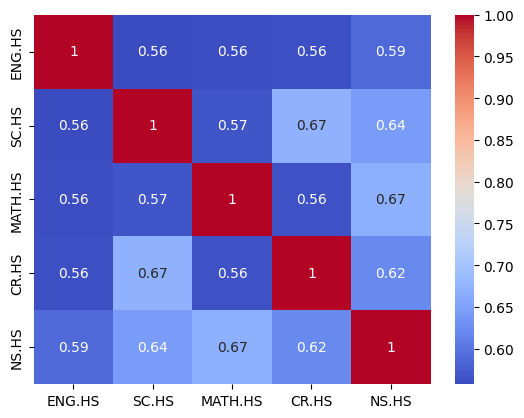

In [ ]:
corr = education_only_df[numeric_columns].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
education_only_df.groupby('degree.focus')[numeric_columns].mean()

,ENG.HS,SC.HS,MATH.HS,CR.HS,NS.HS
degree.focus,,,,,
ADMINISTRATIVE AND RELATED ENGINEERING,61.620767,59.068728,61.536892,59.685814,59.676518
ADVERTISING AND RELATED,56.881436,55.139901,54.668868,56.499848,54.589639
"AGRICULTURAL, FORESTRY AND RELATED ENGINEERING",53.530443,57.116138,58.954072,57.060863,58.558139
"AGROINDUSTRIAL, FOOD AND RELATED ENGINEERING",54.217804,55.916489,58.181009,56.347501,57.480768
"AGRONOMICAL, LIVESTOCK AND RELATED ENGINERING",51.098068,55.027636,55.562805,54.851996,55.771551
AGRONOMY,48.345556,51.942875,52.735097,51.660970,52.507972
ANTHROPOLOGY AND LIBERAL ARTS,65.682430,62.868198,60.760442,63.328512,61.622961
ARCHITECTURE,59.019148,56.722776,58.992539,57.608607,57.798786
BACTERIOLOGY,54.894162,56.942994,56.819961,57.888813,58.078154


# Preprocessing

### Encoding and Standardization

In [6]:
df1_encoded = education_only_df.copy()
df1_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466390 entries, 0 to 466389
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ENG.HS           466390 non-null  float64
 1   SC.HS            466390 non-null  float64
 2   MATH.HS          466390 non-null  float64
 3   CR.HS            466390 non-null  float64
 4   NS.HS            466390 non-null  float64
 5   degree           466390 non-null  object 
 6   degree.focus     466390 non-null  object 
 7   gender           466390 non-null  object 
 8   fems             466390 non-null  object 
 9   fefs             466390 non-null  object 
 10  int.s            466390 non-null  float64
 11  comp.s           466390 non-null  float64
 12  wasm.s           466390 non-null  float64
 13  car.s            466390 non-null  float64
 14  t.cred           466390 non-null  int64  
 15  t.parents        466390 non-null  int64  
 16  t.own            466390 non-null  int6

In [10]:
# Define the categories for each column
categories_dict = {
    'fefs': [
        'primary school complete', 'complete professional education',
        'incomplete primary school', 'complete secondary school',
        'incomplete secondary school', 'incomplete professional education',
        'does not know', 'complete technical degree', 'postgraduate',
        'incomplete technical degree', 'does not apply'
    ],
    'fems': [
        'primary school complete', 'complete professional education',
        'incomplete primary school', 'complete secondary school',
        'incomplete secondary school', 'incomplete professional education',
        'does not know', 'complete technical degree', 'postgraduate',
        'incomplete technical degree', 'does not apply'
    ],
    'gender': [
        'M', 'F',
    ]
}

# Apply OrdinalEncoder to each column
encoder = OrdinalEncoder(categories=list(categories_dict.values()))
columns_to_encode = list(categories_dict.keys())

# Fit and transform the columns
df1_encoded[columns_to_encode] = encoder.fit_transform(education_only_df[columns_to_encode])

# One-hot encode fofu and fomu columns
# df_encoded = pd.get_dummies(df_encoded, columns=['fofu', 'fomu'])


In [11]:
target = 'degree.category'
X_cols_to_drop = ['degree.focus', 'degree', 'degree.category']

In [12]:
# Set degree as Target
Y = df1_encoded[target]
X = df1_encoded.drop(columns=X_cols_to_drop)

In [13]:
# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Encode target labels as integers
le = LabelEncoder()
Y = le.fit_transform(Y)

### Feature Selection

In [14]:
mi_scores = mutual_info_classif(X, Y, random_state=42)

mi_df = pd.DataFrame({
    "Feature": df1_encoded.drop(columns=X_cols_to_drop).columns,
    "MI Score": mi_scores
}).sort_values(by="MI Score", ascending=False)

print("Mutual Information Scores:")
print(mi_df)

top_k = 10
selected_features = mi_df.head(top_k)["Feature"].tolist()
X_selected = X[:, [df1_encoded.drop(columns=['degree', 'degree.focus']).columns.get_loc(col) for col in selected_features]]

print("\nSelected features:", selected_features)

Mutual Information Scores:
      Feature  MI Score
2     MATH.HS  0.046393
5      gender  0.037800
4       NS.HS  0.034451
14      t.own  0.024321
0      ENG.HS  0.024230
3       CR.HS  0.021904
1       SC.HS  0.019901
13  t.parents  0.018943
8       int.s  0.018213
11      car.s  0.016452
12     t.cred  0.015250
10     wasm.s  0.014836
6        fems  0.012753
9      comp.s  0.012521
7        fefs  0.011802

Selected features: ['MATH.HS', 'gender', 'NS.HS', 't.own', 'ENG.HS', 'CR.HS', 'SC.HS', 't.parents', 'int.s', 'car.s']


In [15]:
# Select the top k features based on mutual information scores
X = X_selected

### Train Test Split and Resampling

In [16]:
X_train, X_test, y_train, y_test  = train_test_split(X, Y, test_size=0.2, random_state=42)

In [17]:
# Resampling to ensure class balance
# Check class distribution before resampling
print("Class distribution before resampling:", Counter(y_train))

# Apply RandomUnderSampler for undersampling
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

# Check class distribution after resampling
print("Class distribution after resampling:", Counter(y_train_resampled))

Class distribution before resampling: Counter({np.int64(7): 131672, np.int64(2): 94775, np.int64(3): 48479, np.int64(5): 37095, np.int64(0): 16102, np.int64(8): 14440, np.int64(1): 10785, np.int64(6): 6782, np.int64(4): 6597, np.int64(9): 6385})
Class distribution after resampling: Counter({np.int64(0): 6385, np.int64(1): 6385, np.int64(2): 6385, np.int64(3): 6385, np.int64(4): 6385, np.int64(5): 6385, np.int64(6): 6385, np.int64(7): 6385, np.int64(8): 6385, np.int64(9): 6385})


# Training

In [18]:
def print_top_k_accuracy_per_class(model, X_test, y_test, le, k_values=[3, 5]):
    """
    Calculates and prints top-k accuracy per class for a given model.

    Args:
        model: Trained machine learning model with a predict_proba method.
        X_test: Test feature data.
        y_test: True test labels.
        le: LabelEncoder used to transform the target labels.
        k_values: A list of k values for which to calculate top-k accuracy.
    """
    unique_classes = np.unique(y_test)

    for k in k_values:
        print(f"\n{type(model).__name__} Top {k} Accuracy per Class:")
        for class_label in unique_classes:
            # Get indices for the current class in the test set
            class_indices = np.where(y_test == class_label)[0]
            if len(class_indices) > 0:
                # Filter y_test and predictions for the current class
                y_test_class = y_test[class_indices]
                y_pred_proba_class = model.predict_proba(X_test[class_indices])
                # Calculate top k accuracy for the current class
                topk_accuracy = top_k_accuracy_score(y_test_class, y_pred_proba_class, k=k, labels=unique_classes)
                print(f"Class {le.classes_[class_label]}: {topk_accuracy:.4f}")
            else:
                print(f"Class {le.classes_[class_label]}: No samples in test set")

## Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train_resampled, y_train_resampled)
rf_score = rf.score(X_train_resampled, y_train_resampled)
print("accuracy: " + str(rf_score))

accuracy: 0.28993621545003545


In [ ]:
rf_test_score = rf.score(X_test, y_test)
print("accuracy: " + str(rf_test_score))

accuracy: 0.13518252675999345


In [ ]:
from sklearn.metrics import top_k_accuracy_score

# Calculate top 5 and top 3 accuracy
rf_tuned_top5_accuracy = top_k_accuracy_score(y_test, rf.predict_proba(X_test), k=5, labels=np.unique(y_train_resampled))
rf_tuned_top3_accuracy = top_k_accuracy_score(y_test, rf.predict_proba(X_test), k=3, labels=np.unique(y_train_resampled))


print(f"Random Forest Top 5 Accuracy: {rf_tuned_top5_accuracy}")
print(f"Random Forest Top 3 Accuracy: {rf_tuned_top3_accuracy}")

Random Forest Top 5 Accuracy: 0.6960295973716917
Random Forest Top 3 Accuracy: 0.45919281647124566


In [ ]:
print_top_k_accuracy_per_class(rf, X_test, y_test, le)

Random Forest Top 5 Accuracy per Class:
Class AGRICULTURE & ENVIRONMENTAL SCIENCES: 0.7887
Class ARTS & DESIGN: 0.6881
Class BUSINESS & MANAGEMENT: 0.6875
Class CORE ENGINEERING: 0.6888
Class ELECTRICAL & ELECTRONICS ENGINEERING: 0.8009
Class HEALTH & CLINICAL SCIENCES: 0.7077
Class NATURAL & BASIC SCIENCES: 0.6760
Class OTHER / SPECIALIZED PROGRAMS: 0.6843
Class SOCIAL SCIENCES & HUMANITIES: 0.6836
Class SPECIALIZED ENGINEERING: 0.7131

Random Forest Top 3 Accuracy per Class:
Class AGRICULTURE & ENVIRONMENTAL SCIENCES: 0.4207
Class ARTS & DESIGN: 0.4868
Class BUSINESS & MANAGEMENT: 0.3623
Class CORE ENGINEERING: 0.4181
Class ELECTRICAL & ELECTRONICS ENGINEERING: 0.7387
Class HEALTH & CLINICAL SCIENCES: 0.5393
Class NATURAL & BASIC SCIENCES: 0.4050
Class OTHER / SPECIALIZED PROGRAMS: 0.4884
Class SOCIAL SCIENCES & HUMANITIES: 0.5355
Class SPECIALIZED ENGINEERING: 0.5722


### Hyper Parameter Tuning

In [ ]:
# Objective function for RandomForestClassifier with Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "random_state": 42,
    }

    # Initialize and train the RandomForestClassifier
    rf_clf = RandomForestClassifier(**params)
    rf_clf.fit(X_train_resampled, y_train_resampled) # Use resampled data for training

    # Predict probabilities
    preds_proba = rf_clf.predict_proba(X_test)

    # Calculate top 5 accuracy
    top5_accuracy = top_k_accuracy_score(y_test, preds_proba, k=5, labels=np.unique(y_train_resampled))

    return top5_accuracy

# Run study
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=50, timeout=6000, show_progress_bar=False)

# Results
print("Best params:", study.best_params)
print("Best top 5 accuracy:", study.best_value)

[I 2025-10-19 14:21:27,931] A new study created in memory with name: no-name-90b8788c-1728-4363-bb5e-97b1e08551e7
[I 2025-10-19 14:21:57,389] Trial 0 finished with value: 0.6726850558322816 and parameters: {'n_estimators': 148, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 1, 'criterion': 'gini'}. Best is trial 0 with value: 0.6726850558322816.
[I 2025-10-19 14:22:14,658] Trial 1 finished with value: 0.6975807617084003 and parameters: {'n_estimators': 176, 'max_depth': 11, 'min_samples_split': 15, 'min_samples_leaf': 19, 'criterion': 'gini'}. Best is trial 1 with value: 0.6975807617084003.
[I 2025-10-19 14:22:27,014] Trial 2 finished with value: 0.6981877390575473 and parameters: {'n_estimators': 150, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 18, 'criterion': 'gini'}. Best is trial 2 with value: 0.6981877390575473.
[I 2025-10-19 14:22:36,447] Trial 3 finished with value: 0.6818186197527771 and parameters: {'n_estimators': 57, 'max_depth': 19, 'min_sampl

Best params: {'n_estimators': 195, 'max_depth': 9, 'min_samples_split': 19, 'min_samples_leaf': 16, 'criterion': 'gini'}
Best top 5 accuracy: 0.6988139855288892


In [ ]:
rf_tuned = RandomForestClassifier(n_estimators=149, random_state=42, max_depth=10, min_samples_split = 9, min_samples_leaf= 18, criterion='gini')
rf_tuned.fit(X_train_resampled, y_train_resampled)
rf_tuned_train_score = rf_tuned.score(X_train_resampled, y_train_resampled)
print("Train accuracy: " + str(rf_tuned_train_score))

Train accuracy: 0.44698932531868585
Train accuracy: 0.371329676766601


In [ ]:
rf_tuned_test_score = rf_tuned.score(X_test, y_test)
print("Train accuracy: " + str(rf_tuned_test_score))

In [ ]:
from sklearn.metrics import top_k_accuracy_score

# Calculate top 5 and top 10 accuracy
rf_tuned_top5_accuracy = top_k_accuracy_score(y_test, rf_tuned.predict_proba(X_test), k=5, labels=np.unique(y_train_resampled))
rf_tuned_top10_accuracy = top_k_accuracy_score(y_test, rf_tuned.predict_proba(X_test), k=10, labels=np.unique(y_train_resampled))


print(f"Random Forest Tuned Top 5 Accuracy: {rf_tuned_top5_accuracy}")
print(f"Random Forest Tuned Top 10 Accuracy: {rf_tuned_top10_accuracy}")

## XGB

In [19]:
xgb_clf = XGBClassifier(n_estimators=100, max_depth=10, random_state=42, eval_metric='mlogloss')
xgb_clf.fit(X_train_resampled, y_train_resampled)
xgb_score = xgb_clf.score(X_train_resampled, y_train_resampled)
print("XGB accuracy:", xgb_score)

XGB accuracy: 0.8119185591229444


In [20]:
xgb_test_score = xgb_clf.score(X_test, y_test)
print("accuracy: " + str(xgb_test_score))

accuracy: 0.15259761144106862


In [21]:
from sklearn.metrics import top_k_accuracy_score

# Calculate top 5 and top 3 accuracy
xgb_clf_top5_accuracy = top_k_accuracy_score(y_test, xgb_clf.predict_proba(X_test), k=5, labels=np.unique(y_train_resampled))
xgb_clf_top3_accuracy = top_k_accuracy_score(y_test, xgb_clf.predict_proba(X_test), k=3, labels=np.unique(y_train_resampled))


print(f"XGB Top 5 Accuracy: {xgb_clf_top5_accuracy}")
print(f"XGB Top 3 Accuracy: {xgb_clf_top3_accuracy}")

XGB Top 5 Accuracy: 0.6629966337185618
XGB Top 3 Accuracy: 0.4315808657990094


In [22]:
print_top_k_accuracy_per_class(xgb_clf, X_test, y_test, le)


XGBClassifier Top 3 Accuracy per Class:
Class AGRICULTURE & ENVIRONMENTAL SCIENCES: 0.4261
Class ARTS & DESIGN: 0.4683
Class BUSINESS & MANAGEMENT: 0.4171
Class CORE ENGINEERING: 0.4056
Class ELECTRICAL & ELECTRONICS ENGINEERING: 0.6443
Class HEALTH & CLINICAL SCIENCES: 0.4293
Class NATURAL & BASIC SCIENCES: 0.4302
Class OTHER / SPECIALIZED PROGRAMS: 0.4204
Class SOCIAL SCIENCES & HUMANITIES: 0.5303
Class SPECIALIZED ENGINEERING: 0.5913

XGBClassifier Top 5 Accuracy per Class:
Class AGRICULTURE & ENVIRONMENTAL SCIENCES: 0.7157
Class ARTS & DESIGN: 0.6714
Class BUSINESS & MANAGEMENT: 0.6386
Class CORE ENGINEERING: 0.6554
Class ELECTRICAL & ELECTRONICS ENGINEERING: 0.7634
Class HEALTH & CLINICAL SCIENCES: 0.6791
Class NATURAL & BASIC SCIENCES: 0.6691
Class OTHER / SPECIALIZED PROGRAMS: 0.6577
Class SOCIAL SCIENCES & HUMANITIES: 0.7043
Class SPECIALIZED ENGINEERING: 0.7442


### Hyper Parameter Tuning

In [ ]:
# Objective function with pruning and additional regularization

def objective(trial):
    params = {
        "objective": "multi:softprob", # Changed objective to multi:softprob to get probabilities
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "random_state": 42,
        "num_class": len(le.classes_),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "lambda": trial.suggest_float("lambda", 1, 5),  # L2 regularization
        "alpha": trial.suggest_float("alpha", 0, 5),    # L1 regularization
        "n_estimators": trial.suggest_int("n_estimators", 50, 100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
    }

    dtrain = xgb.DMatrix(X_train_resampled, label=y_train_resampled) # Use resampled data for training DMatrix
    dvalid = xgb.DMatrix(X_test, label=y_test)

    # Optuna pruning callback
    pruning_callback = XGBoostPruningCallback(trial, "validation-mlogloss")

    # Train with validation set for pruning and early stopping
    bst = xgb.train(
        params,
        dtrain,
        evals=[(dtrain, "train"), (dvalid, "validation")],
        callbacks=[pruning_callback],
        early_stopping_rounds=20,
        verbose_eval=False,
    )

    # Predict and evaluate
    preds_proba = bst.predict(dvalid) # predict now returns probabilities directly
    # Calculate top 5 accuracy
    top5_accuracy = top_k_accuracy_score(y_test, preds_proba, k=5, labels=np.unique(y_train_resampled))

    return top5_accuracy

# Run study with pruning
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=50, timeout=6000, show_progress_bar=False)

# Results
print("Best params:", study.best_params)
print("Best accuracy:", study.best_value)

[I 2025-10-21 09:00:39,031] A new study created in memory with name: no-name-511ddef9-55c8-445a-9b62-8fa14608f7b7
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [09:00:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()
[I 2025-10-21 09:00:40,698] Trial 0 finished with value: 0.6999315946162072 and parameters: {'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.6651868752351796, 'colsample_bytree': 0.8794332702590071, 'gamma': 0.5174236945191613, 'lambda': 3.568935309832264, 'alpha': 0.8041045985582695, 'n_estimators': 91, 'learning_rate': 0.2204096191332631}. Best is trial 0 with value: 0.6999315946162072.
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [09:00:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()
[I 2025-10-21 09:00:42,137] Trial 

Best params: {'max_depth': 7, 'min_child_weight': 3, 'subsample': 0.6374988050698834, 'colsample_bytree': 0.8654102204072376, 'gamma': 1.7658511436799869, 'lambda': 4.966263065376992, 'alpha': 3.350071981991793, 'n_estimators': 61, 'learning_rate': 0.05769069325335802}
Best accuracy: 0.7002206314491344


In [ ]:
# 'max_depth': 6, 'min_child_weight': 7, 'subsample': 0.8230945653139117, 'colsample_bytree': 0.846485148315364, 'gamma': 2.0865528158327704, 'lambda': 4.36182442007958, 'alpha': 2.9322335585109927, 'n_estimators': 91, 'learning_rate': 0.040329215676110045
xgb_tuned = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    **study.best_params # Use the best parameters from the Optuna study
    )
xgb_tuned.fit(X_train_resampled, y_train_resampled)
xgb_score = xgb_tuned.score(X_train_resampled, y_train_resampled) # Use xgb_tuned to calculate the score
print("XGB accuracy:", xgb_score)
xgb_test_score = xgb_tuned.score(X_test, y_test) # Use xgb_tuned to calculate the score
print("accuracy: " , xgb_test_score)

XGB accuracy: 0.22226553271911173
accuracy:  0.14633934851097857


In [24]:
# 'max_depth': 6, 'min_child_weight': 7, 'subsample': 0.8230945653139117, 'colsample_bytree': 0.846485148315364, 'gamma': 2.0865528158327704, 'lambda': 4.36182442007958, 'alpha': 2.9322335585109927, 'n_estimators': 91, 'learning_rate': 0.040329215676110045
xgb_tuned = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    max_depth=7,
    min_child_weight=3,
    subsample=0.6374988050698834,
    colsample_bytree=0.8654102204072376,
    gamma=1.7658511436799869,
    reg_lambda=4.966263065376992,
    alpha=3.350071981991793,
    n_estimators=61,
    learning_rate=0.05769069325335802
    )
xgb_tuned.fit(X_train_resampled, y_train_resampled)
xgb_score = xgb_tuned.score(X_train_resampled, y_train_resampled) # Use xgb_tuned to calculate the score
print("XGB accuracy:", xgb_score)
xgb_test_score = xgb_tuned.score(X_test, y_test) # Use xgb_tuned to calculate the score
print("accuracy: " , xgb_test_score)

XGB accuracy: 0.23423649177760375
accuracy:  0.13886446964986385


In [25]:
from sklearn.metrics import top_k_accuracy_score

# Calculate top 5 and top 10 accuracy
xgb_tuned_top5_accuracy = top_k_accuracy_score(y_test, xgb_tuned.predict_proba(X_test), k=5, labels=np.unique(y_train_resampled))
xgb_tuned_top10_accuracy = top_k_accuracy_score(y_test, xgb_tuned.predict_proba(X_test), k=3, labels=np.unique(y_train_resampled))


print(f"XGB Top 5 Accuracy: {xgb_tuned_top5_accuracy}")
print(f"XGB Top 3 Accuracy: {xgb_tuned_top10_accuracy}")

XGB Top 5 Accuracy: 0.698342588820515
XGB Top 3 Accuracy: 0.47088273762301935


In [ ]:
print_top_k_accuracy_per_class(xgb_tuned, X_test, y_test, le)


XGBClassifier Top 3 Accuracy per Class:
Class AGRICULTURE & ENVIRONMENTAL SCIENCES: 0.4178
Class ARTS & DESIGN: 0.4956
Class BUSINESS & MANAGEMENT: 0.3840
Class CORE ENGINEERING: 0.4198
Class ELECTRICAL & ELECTRONICS ENGINEERING: 0.7103
Class HEALTH & CLINICAL SCIENCES: 0.5312
Class NATURAL & BASIC SCIENCES: 0.4235
Class OTHER / SPECIALIZED PROGRAMS: 0.4958
Class SOCIAL SCIENCES & HUMANITIES: 0.5401
Class SPECIALIZED ENGINEERING: 0.5694

XGBClassifier Top 5 Accuracy per Class:
Class AGRICULTURE & ENVIRONMENTAL SCIENCES: 0.7777
Class ARTS & DESIGN: 0.6787
Class BUSINESS & MANAGEMENT: 0.6728
Class CORE ENGINEERING: 0.7099
Class ELECTRICAL & ELECTRONICS ENGINEERING: 0.7855
Class HEALTH & CLINICAL SCIENCES: 0.7086
Class NATURAL & BASIC SCIENCES: 0.6865
Class OTHER / SPECIALIZED PROGRAMS: 0.7051
Class SOCIAL SCIENCES & HUMANITIES: 0.7030
Class SPECIALIZED ENGINEERING: 0.6994


## KNN

In [ ]:
# Function to determin the optimal features to determine a target and the optimal K for that combination of features
def find_optimal_features_and_k(X, y, k_range=range(5, 21)):
    results = []

    best_score = 0
    best_k = None
    # Loop through k values
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X, y)
        score = knn.score(X, y)

        # Update best parameters if better score is found
        if score > best_score:
            best_score = score
            best_k = k

        # Append results
        results.append({
            'k': k,
            'accuracy': score
        })

    print("optimal_k: " + str(best_k) + "\nbest_accuracy: " + str(best_score))

    return pd.DataFrame(results)


In [ ]:
results_df = find_optimal_features_and_k(X_train_resampled, y_train_resampled)

optimal_k: 5
best_accuracy: 0.39370422867942356


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_resampled, y_train_resampled)
knn_score = knn.score(X_train_resampled, y_train_resampled)
print("KNN accuracy: " + str(knn_score))

KNN accuracy: 0.39370422867942356


In [ ]:
knn_test_score = knn.score(X_test, y_test)
print("accuracy: " + str(knn_test_score))

accuracy: 0.12960411588450088


In [ ]:
# Calculate top 5 and top 10 accuracy
xgb_tuned_top5_accuracy = top_k_accuracy_score(y_test, knn.predict_proba(X_test), k=5, labels=np.unique(y_train_resampled))
xgb_tuned_top10_accuracy = top_k_accuracy_score(y_test, knn.predict_proba(X_test), k=3, labels=np.unique(y_train_resampled))


print(f"XGB Top 5 Accuracy: {xgb_tuned_top5_accuracy}")
print(f"XGB Top 3 Accuracy: {xgb_tuned_top10_accuracy}")

XGB Top 5 Accuracy: 0.5529659996338867
XGB Top 3 Accuracy: 0.37891765340629907


## GMLNET

In [ ]:
# GLMNET: Logistic Regression with Elastic Net regularization
glmnet = LogisticRegressionCV(
    Cs=10,
    # cv=5,
    penalty='elasticnet',
    solver='saga',
    l1_ratios=[.1, .5, .7, .9, 1],
    # multi_class='multinomial',
    # max_iter=1000,
    random_state=42
 )
glmnet.fit(X_train, y_train)
glmnet_train_score = glmnet.score(X_train, y_train)
print('GLMNET train accuracy:', glmnet_train_score)

GLMNET train accuracy: 0.1548505665176507


In [ ]:
glmnet_test_score = glmnet.score(X_test, y_test)
print('GLMNET test accuracy:', glmnet_test_score)

GLMNET test accuracy: 0.15448055263842456


In [ ]:
from sklearn.metrics import top_k_accuracy_score

# Calculate top 5 and top 10 accuracy
glmnet_top5_accuracy = top_k_accuracy_score(y_test, glmnet.predict_proba(X_test), k=5, labels=np.unique(y_train_resampled))
glmnet_top10_accuracy = top_k_accuracy_score(y_test, glmnet.predict_proba(X_test), k=10, labels=np.unique(y_train_resampled))


print(f"GMNET Top 5 Accuracy: {glmnet_top5_accuracy}")
print(f"GMNET Top 10 Accuracy: {glmnet_top10_accuracy}")

GMNET Top 5 Accuracy: 0.5069802395151889
GMNET Top 10 Accuracy: 0.7117821047662174


## SVM

In [ ]:
svm_clf = SVC(kernel='linear', C=1, random_state=42)
svm_clf.fit(X_train, y_train)
svm_train_score = svm_clf.score(X_train, y_train)
print('SVM train accuracy:', svm_train_score)

SVM train accuracy: 0.3892242719452793


In [ ]:
svm_test_score = svm_clf.score(X_test, y_test)
print('SVM test accuracy:', svm_test_score)

SVM test accuracy: 0.3375898610149635


# Export Models

In [26]:
import joblib
import os

# Define the directory to save the models and encoders
export_dir = '/content/drive/My Drive/IS_II/exported_model'
os.makedirs(export_dir, exist_ok=True)

# Export the tuned XGBoost model
model_filename = os.path.join(export_dir, 'xgb_tuned_model.joblib')
joblib.dump(xgb_tuned, model_filename)
print(f"Tuned XGBoost model exported to: {model_filename}")

# Export the StandardScaler
scaler_filename = os.path.join(export_dir, 'scaler.joblib')
joblib.dump(scaler, scaler_filename)
print(f"Scaler exported to: {scaler_filename}")

# Export the OrdinalEncoder
encoder_filename = os.path.join(export_dir, 'ordinal_encoder.joblib')
joblib.dump(encoder, encoder_filename)
print(f"Ordinal Encoder exported to: {encoder_filename}")

# Export the LabelEncoder
label_encoder_filename = os.path.join(export_dir, 'label_encoder.joblib')
joblib.dump(le, label_encoder_filename)
print(f"Label Encoder exported to: {label_encoder_filename}")

# Export the list of selected features
features_filename = os.path.join(export_dir, 'selected_features.joblib')
joblib.dump(selected_features, features_filename)
print(f"Selected features list exported to: {features_filename}")

Tuned XGBoost model exported to: /content/drive/My Drive/IS_II/exported_model/xgb_tuned_model.joblib
Scaler exported to: /content/drive/My Drive/IS_II/exported_model/scaler.joblib
Ordinal Encoder exported to: /content/drive/My Drive/IS_II/exported_model/ordinal_encoder.joblib
Label Encoder exported to: /content/drive/My Drive/IS_II/exported_model/label_encoder.joblib
Selected features list exported to: /content/drive/My Drive/IS_II/exported_model/selected_features.joblib


In [ ]:
import joblib
import os
import numpy as np
import pandas as pd

# Define the directory where the files were exported
export_dir = '/content/drive/My Drive/IS_II/exported_model'

# Load the exported files
loaded_model = joblib.load(os.path.join(export_dir, 'xgb_tuned_model.joblib'))
loaded_scaler = joblib.load(os.path.join(export_dir, 'scaler.joblib'))
loaded_encoder = joblib.load(os.path.join(export_dir, 'ordinal_encoder.joblib'))
loaded_label_encoder = joblib.load(os.path.join(export_dir, 'label_encoder.joblib'))
loaded_features = joblib.load(os.path.join(export_dir, 'selected_features.joblib'))

print("Exported files loaded successfully!")

# Create a sample data point (replace with actual sample data if available)
# This sample data should have the same columns as the original data before dropping target and focus columns
# and in the same order as the original df1_encoded columns before feature selection.
# For demonstration, let's create a sample based on the columns in df1_encoded before dropping.
# You would replace the values here with actual data you want to test.
sample_data = {
    'ENG.HS': [50.0], 'SC.HS': [60.0], 'MATH.HS': [70.0], 'CR.HS': [55.0], 'NS.HS': [65.0],
    'degree': ['SOME DEGREE'], 'degree.focus': ['SOME FOCUS'], 'gender': ['M'], 'fems': ['complete secondary school'],
    'fefs': ['complete secondary school'], 'int.s': [1.0], 'comp.s': [0.0], 'wasm.s': [1.0], 'car.s': [0.0],
    't.cred': [1], 't.parents': [0], 't.own': [1]
}

# Create a pandas DataFrame from the sample data
sample_df = pd.DataFrame(sample_data)

# Apply the same preprocessing steps as used for training data

# 1. Ordinal Encode categorical features (fems, fefs, gender)
# Ensure the order of columns for encoding matches the training data
# Corrected the order of columns to match the original fitting
cols_to_encode = ['fefs', 'fems', 'gender']
sample_df[cols_to_encode] = loaded_encoder.transform(sample_df[cols_to_encode])


# 2. Drop the columns that were dropped from the training data
cols_to_drop = ['degree.focus', 'degree']
sample_df = sample_df.drop(columns=cols_to_drop)


# Ensure the order of columns in the sample_df matches the order of features used during training
# This is crucial because the scaler and model expect features in a specific order.
# We can use the columns from df1_encoded after dropping the target and focus columns
# which were used as the basis for feature selection.
original_feature_columns = df1_encoded.drop(columns=['degree.focus', 'degree', 'degree.category']).columns
sample_df = sample_df[original_feature_columns]


# 3. Scale the numerical features
sample_scaled = loaded_scaler.transform(sample_df)

# 4. Select the same features that were used for training
# The loaded_features list contains the names of the selected features.
# We need to find the indices of these features in the scaled sample data.
feature_indices = [original_feature_columns.get_loc(col) for col in loaded_features]
sample_final = sample_scaled[:, feature_indices]


# Make a prediction using the loaded model
# The model predicts probabilities for each class
predictions_proba = loaded_model.predict_proba(sample_final)

# Get the predicted class label (index with the highest probability)
predicted_class_index = np.argmax(predictions_proba, axis=1)[0]

# Decode the predicted class index back to the original label
predicted_degree_category = loaded_label_encoder.inverse_transform([predicted_class_index])[0]

print(f"\nSample data: {sample_data}")
print(f"Predicted degree category: {predicted_degree_category}")

# Optionally, you can also get the top-k predictions
k = 5 # Example k
top_k_indices = np.argsort(predictions_proba, axis=1)[:, -k:][0][::-1]
top_k_degree_categories = loaded_label_encoder.inverse_transform(top_k_indices)
top_k_probabilities = predictions_proba[0, top_k_indices]

print(f"Top {k} predicted degree categories with probabilities:")
for category, probability in zip(top_k_degree_categories, top_k_probabilities):
    print(f"- {category}: {probability:.4f}")

Exported files loaded successfully!

Sample data: {'ENG.HS': [50.0], 'SC.HS': [60.0], 'MATH.HS': [70.0], 'CR.HS': [55.0], 'NS.HS': [65.0], 'degree': ['SOME DEGREE'], 'degree.focus': ['SOME FOCUS'], 'gender': ['M'], 'fems': ['complete secondary school'], 'fefs': ['complete secondary school'], 'int.s': [1.0], 'comp.s': [0.0], 'wasm.s': [1.0], 'car.s': [0.0], 't.cred': [1], 't.parents': [0], 't.own': [1]}
Predicted degree category: ELECTRICAL & ELECTRONICS ENGINEERING
Top 5 predicted degree categories: ['ELECTRICAL & ELECTRONICS ENGINEERING' 'CORE ENGINEERING'
 'AGRICULTURE & ENVIRONMENTAL SCIENCES' 'NATURAL & BASIC SCIENCES'
 'BUSINESS & MANAGEMENT']
